# Projet Deep Learning
Emma Vulliez, Elisa Forthoffer, Morgan Beaumé

In [1]:
%matplotlib inline

In [2]:
import os
import glob
import math
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

# YOLO (Ultralytics)
from ultralytics import YOLO

from IPython.display import display

In [ ]:
#pour faire tourner sur GPU sinon mettre en commentaire
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0))



CUDA available: True
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


Fine-tunning

In [ ]:
# mettre le chemin vers votre landingpad.yaml
DATA_YAML = "./data_helipadV2/landingpad.yaml"

#les chemins vers les images/labels de train
IMG_DIR_TRAIN = "./data_helipadV2/train/images"
LBL_DIR_TRAIN = "./data_helipadV2/train/labels"

# Changer les poids si besoin (ex: yolov8n.pt, yolov11n.pt)
MODEL_WEIGHTS = "yolov8n.pt"
ft_model = YOLO(MODEL_WEIGHTS)

ft_model.train(
    data=DATA_YAML,
   epochs=12,      #adapter selon besoin
    imgsz=416,
   batch=8,        #adapter selon GPU/CPU
   device="cuda",
   workers=2
)

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.9.25 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data_helipadV2/landingpad.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025337B09580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480


0: 416x416 (no detections), 27.2ms
1: 416x416 (no detections), 27.2ms
2: 416x416 1 bed, 1 remote, 27.2ms
Speed: 12.5ms preprocess, 27.2ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 1 landing_pad, 10.0ms
1: 416x416 1 landing_pad, 10.0ms
2: 416x416 1 landing_pad, 10.0ms
Speed: 2.4ms preprocess, 10.0ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)


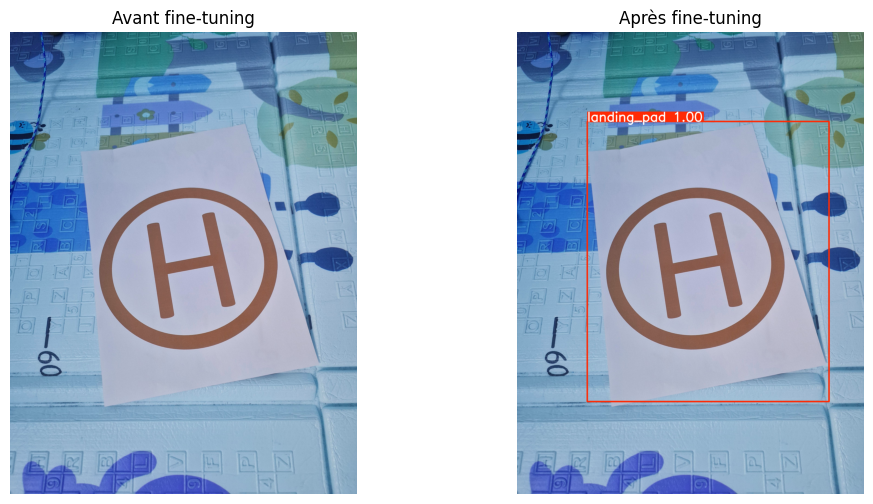

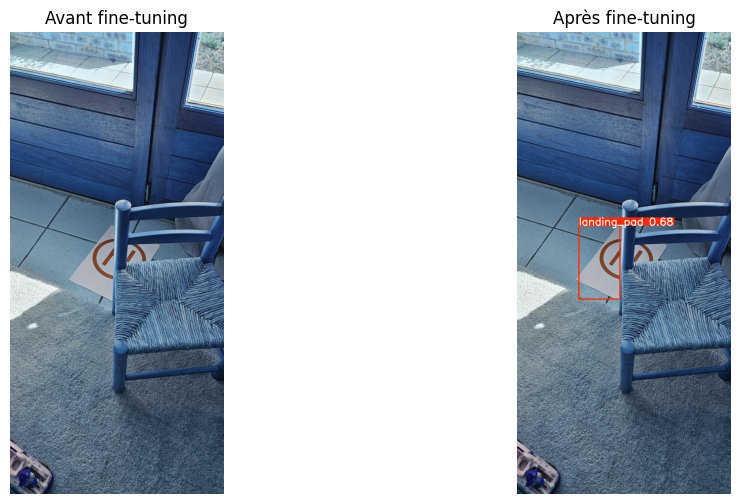

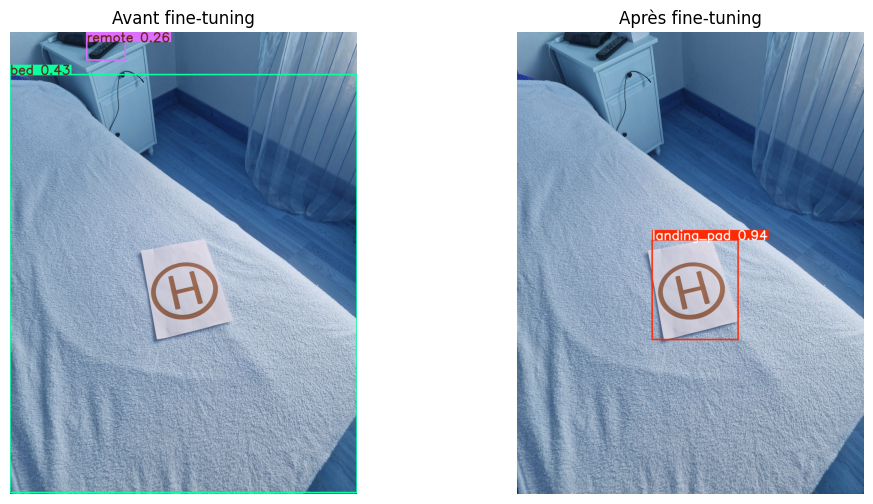

In [ ]:

# Modèle pré-entraîné (avant FT)
base_model = YOLO(MODEL_WEIGHTS)


all_images = [
    os.path.join(IMG_DIR_TRAIN, img)
    for img in os.listdir(IMG_DIR_TRAIN)
    if img.endswith((".jpg", ".png", ".jpeg"))
]
val_images = random.sample(all_images, 3)

base_results = base_model.predict(
    source=val_images,
    imgsz=416,
    conf=0.25,
    device="cuda"
)

ft_results = ft_model.predict(
    source=val_images,
    imgsz=416,
    conf=0.1,
    device="cuda"
)

for i in range(len(val_images)):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(base_results[i].plot())
    axs[0].set_title("Avant fine-tuning")
    axs[0].axis("off")

    axs[1].imshow(ft_results[i].plot())
    axs[1].set_title("Après fine-tuning")
    axs[1].axis("off")


    display(fig)
    plt.close(fig)

Validation du model

In [6]:
model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val(
    data=DATA_YAML,
    split="test",      
    imgsz=416,
    batch=8,
    device="cuda"
)

print(metrics)

Ultralytics 8.4.14  Python-3.9.25 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 843.7228.7 MB/s, size: 1750.2 KB)
val: Scanning C:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\labels.cache... 31 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3s/it 5.2s0.5s6s
                   all         31         26      0.986      0.885      0.974      0.896
Speed: 3.1ms preprocess, 17.0ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to C:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\runs\detect\val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.m

Test du model

In [7]:
model.predict(
    source="./data_helipadV2/test/images",
    imgsz=416,
    conf=0.25,
    save=True
)


image 1/31 c:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\images\coin_maison-2-_jpg.rf.a8b9513a1ae7e84ee2c4336b71c8c978.jpg: 416x320 1 landing_pad, 58.7ms
image 2/31 c:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\images\coin_maison-3-_jpg.rf.094ed7068f57cdc268fd41373ba97104.jpg: 416x320 1 landing_pad, 11.7ms
image 3/31 c:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\images\coin_maison_jpg.rf.5d9df9681aa5f143e481601912f47c38.jpg: 416x320 1 landing_pad, 11.8ms
image 4/31 c:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\images\feuilles-2-_jpg.rf.5fa81b13357b162b1c7efbcef729f08b.jpg: 416x320 1 landing_pad, 11.8ms
image 5/31 c:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\images\feuilles-3-_jpg.rf.396afae62d088881dfd18c0667fc13f9.jpg: 416x320 1 landing_pad, 14.1ms
image 6/31 c:\Users\morga\Documents\ELISA 5\Deep Learning\Projet\data_helipadV2\test\images\feuill

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'landing_pad'}
 obb: None
 orig_img: array([[[111, 133, 168],
         [106, 128, 163],
         [101, 123, 158],
         ...,
         [ 82,  96, 102],
         [ 79,  93,  99],
         [ 76,  90,  96]],
 
        [[103, 125, 160],
         [103, 125, 160],
         [102, 124, 159],
         ...,
         [ 69,  83,  89],
         [ 60,  74,  80],
         [ 58,  72,  78]],
 
        [[ 98, 120, 155],
         [101, 123, 158],
         [105, 127, 162],
         ...,
         [ 67,  81,  87],
         [ 74,  88,  94],
         [ 75,  89,  95]],
 
        ...,
 
        [[157, 172, 198],
         [156, 171, 197],
         [157, 172, 198],
         ...,
         [159, 163, 168],
         [158, 162, 167],
         [159, 163, 168]],
 
        [[160, 175, 201],
         [157, 172, 198],
         [156, 171, 197],
         ...,
         [163

In [ ]:
import cv2
#Charger le meilleur modèle issu du fine-tuning
best_model = YOLO("./runs/detect/train/weights/best.pt") #changer le numéro de train si besoin

def is_safe_to_land(image_path, model, tau_conf, tau_area):
    
    # Lancer l'inférence sur l'image (le seuil de confiance est appliqué ici)
    results = model.predict(image_path, conf=tau_conf, verbose=False)

    for result in results:
        # Dimensions totales de l'image (hauteur, largeur)
        img_h, img_w = result.orig_shape
        img_area = img_h * img_w

        max_relative_area = 0.0
        best_conf = 0.0

#Analyser les boîtes détectées
        for box in result.boxes:
            conf = float(box.conf[0])

#Récupérer les coordonnées de la boîte englobante
            x1, y1, x2, y2 = box.xyxy[0]
            pad_area = float((x2 - x1) * (y2 - y1))

#Calculer l'aire relative de la piste par rapport à l'image complète
            relative_area = pad_area / img_area
            if relative_area > max_relative_area:
                max_relative_area = relative_area
                best_conf = conf

#Si l'aire est suffisante, la zone est Safe
        if max_relative_area >= tau_area:
            return True, best_conf, max_relative_area

#Si on n'a rien détecté ou que la piste est trop petite
    return False, 0.0, 0.0


import pandas as pd

#Mettre le bon chemin vers les images de validation
VAL_IMAGES_DIR = "./data_helipadV2/valid/images"
val_images = glob.glob(os.path.join(VAL_IMAGES_DIR, "*.jpg"))

#Valeurs de seuils à faire varier
tau_conf_values = [0.3, 0.4, 0.5, 0.6, 0.7]
tau_area_values = [0.01, 0.05, 0.10]

results_log = []
print(f"Évaluation sur {len(val_images)} images de validation en cours...")

#Boucle d'expérimentation
for t_conf in tau_conf_values:
    for t_area in tau_area_values:
        safe_count = 0
        total_images = len(val_images)

#Tester chaque image avec la combinaison de seuils en cours
        for img_path in val_images:
            safe, _, _ = is_safe_to_land(img_path, best_model, t_conf, t_area)
            if safe:
                safe_count += 1

#Calcul du pourcentage de scènes jugées "Safe"
        safe_ratio = (safe_count / total_images)* 100 if total_images > 0 else 0

#Sauvegarde des résultats
        results_log.append({
            "Tau_Conf": t_conf,
            "Tau_Area": t_area,
            "Images_Safe": safe_count,
            "Total_Images": total_images,
            "Safe_Ratio (%)": round(safe_ratio, 2)
        })

#Création et affichage du tableau
df_results = pd.DataFrame(results_log)
display(df_results)

#Export dans un tableau Excel
df_results.to_excel("Decision_Experimentation.xlsx", index=False)
print("Résultats sauvegardés avec succès dans 'Decision_Experimentation.xlsx'")

Évaluation sur 32 images de validation en cours...


,Tau_Conf,Tau_Area,Images_Safe,Total_Images,Safe_Ratio (%)
0,0.3,0.01,31,32,96.88
1,0.3,0.05,23,32,71.88
2,0.3,0.10,14,32,43.75
3,0.4,0.01,31,32,96.88
4,0.4,0.05,23,32,71.88
5,0.4,0.10,14,32,43.75
6,0.5,0.01,31,32,96.88
7,0.5,0.05,23,32,71.88
8,0.5,0.10,14,32,43.75
9,0.6,0.01,31,32,96.88


Résultats sauvegardés avec succès dans 'Decision_Experimentation.xlsx' !
